In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from skimage.util import view_as_blocks
import pandas as pd

[layers](https://keras.io/api/layers/)

In [ ]:
# Load the MNIST dataset (28x28 grayscale images of handwritten digits 0-9)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Check data dimension
print("X_train data shape is", X_train.shape)
print("y_train data shape is", y_train.shape)
print("X_test data shape is", X_test.shape)
print("y_test data shape is", y_test.shape)

X_train data shape is (60000, 28, 28)
y_train data shape is (60000,)
X_test data shape is (10000, 28, 28)
y_test data shape is (10000,)


In [ ]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

6


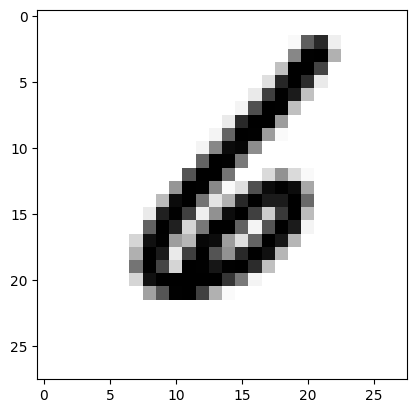

In [ ]:
# Visualise sample data
img_index = 999
print(y_train[img_index])
plt.imshow(X_train[img_index], cmap='gray_r')

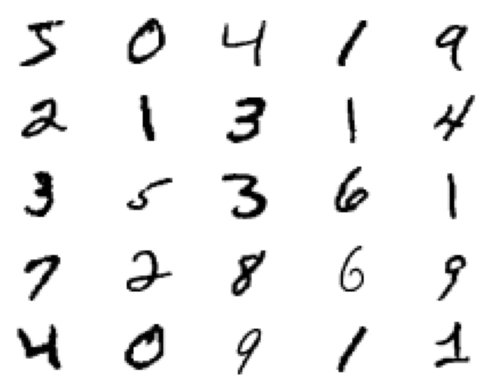

In [ ]:
# plot images from the training dataset
for i in range(25):
	# define subplot
	plt.subplot(5, 5, 1 + i)
	# turn off axis
	plt.axis('off')
	# plot raw pixel data
	plt.imshow(X_train[i], cmap='gray_r')
plt.show()

In [ ]:
# ฟังก์ชันในการคำนวณค่าเฉลี่ยของแต่ละบล็อกขนาด 14x14
def preprocess_images(images):
    processed_images = []
    for img in images:
        # แบ่งภาพออกเป็น 4 บล็อกขนาด 14x14 (แบ่งเป็น 4 สี่เหลี่ยม)
        blocks = [
            img[:14, :14],  # บล็อกที่ 1: ซ้ายบน
            img[:14, 14:],  # บล็อกที่ 2: ขวาบน
            img[14:, :14],  # บล็อกที่ 3: ซ้ายล่าง
            img[14:, 14:],  # บล็อกที่ 4: ขวาล่าง
        ]
        # คำนวณค่าเฉลี่ยในแต่ละบล็อก
        averaged_blocks = [np.mean(block) for block in blocks]
        # สร้างอาร์เรย์ขนาด 1x4 จากค่าเฉลี่ยของแต่ละบล็อก
        processed_images.append(averaged_blocks)

    return np.array(processed_images)

In [ ]:
# เตรียมข้อมูล
x_train_processed = preprocess_images(X_train)
x_test_processed = preprocess_images(X_test)

In [ ]:
x_train_processed.shape

(60000, 4)

In [ ]:
x_train_processed[0]

array([34.13265306, 32.96428571, 34.68877551, 38.64795918])

In [ ]:
# ทำ normalization ให้ค่าอยู่ในช่วง 0-1
x_train_processed = x_train_processed.astype('float32') / 255.0
x_test_processed = x_test_processed.astype('float32') / 255.0

In [ ]:
x_train_processed

array([[0.13385354, 0.12927172, 0.13603441, 0.15156063],
       [0.10362145, 0.2207483 , 0.1839736 , 0.11380553],
       [0.06410564, 0.09307723, 0.09239696, 0.13943577],
       ...,
       [0.11662665, 0.11108443, 0.08179272, 0.13331333],
       [0.05662265, 0.09985994, 0.11182473, 0.14041616],
       [0.05306122, 0.16296518, 0.17613046, 0.02641056]], dtype=float32)

In [ ]:
# แปลง label ให้เป็น one-hot encoding
# output 10 node (10 class เลข 0-9)
y_train_encode = to_categorical(y_train, 10)
y_test_encode = to_categorical(y_test, 10)

In [ ]:
y_train[2]

np.uint8(4)

In [ ]:
y_train_encode[2]

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [ ]:
# สร้างโมเดล MLP
model = Sequential([
    Input(shape=(4,) , name='input'),
    Dense(256, activation='relu', name='layer1'),
    Dense(128, activation='relu', name='layer2'),
    Dense(64, activation='relu', name='layer3'),
    Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,082 (168.29 KB)

 Trainable params: 43,082 (168.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# คอมไพล์โมเดล
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# ฝึกโมเดลกับข้อมูลที่แปลงแล้ว
model.fit(x_train_processed, y_train_encode, epochs=30, batch_size=32, validation_data=(x_test_processed, y_test_encode))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.3709 - loss: 1.7587 - val_accuracy: 0.4903 - val_loss: 1.4151
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4966 - loss: 1.3982 - val_accuracy: 0.5015 - val_loss: 1.3827
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5124 - loss: 1.3424 - val_accuracy: 0.5214 - val_loss: 1.3293
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5150 - loss: 1.3291 - val_accuracy: 0.5137 - val_loss: 1.3236
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5180 - loss: 1.3193 - val_accuracy: 0.5100 - val_loss: 1.3344
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5172 - loss: 1.3184 - val_accuracy: 0.5104 - val_loss: 1.3326
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5166 - loss: 1.3157 - val_accuracy: 0.5217 - val_loss: 1.3058
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5197 - loss: 1.3067 - 

In [ ]:
model.get_weights()

[array([[-0.11715423, -0.02153833, -0.08018526, ..., -0.5546549 ,
         -0.11850527, -0.2262263 ],
        [-0.07964958, -0.4859029 , -0.01882057, ...,  0.42966196,
         -0.05595951,  0.41408756],
        [ 0.00338349,  0.36275685, -0.66254985, ..., -0.30375615,
          0.09756221, -0.49225956],
        [ 0.0082445 ,  0.427917  ,  0.6095997 , ...,  0.05409566,
         -0.10733945, -0.4534169 ]], dtype=float32),
 array([ 0.00000000e+00, -1.51797570e-02,  2.40670022e-04,  9.33421478e-02,
         0.00000000e+00, -1.11918993e-01, -1.22384671e-02, -8.11990444e-03,
        -9.48308595e-03, -1.30894125e-01, -6.31740596e-03,  0.00000000e+00,
         3.89960818e-02, -3.98779474e-03, -7.03974441e-02, -5.77027677e-03,
         1.24709323e-01,  9.30756778e-02, -7.41106793e-02,  0.00000000e+00,
        -2.81553306e-02, -4.75088581e-02, -3.73535580e-03, -6.56899530e-03,
         0.00000000e+00,  1.59319062e-02,  5.50168753e-02, -9.76723954e-02,
         0.00000000e+00, -1.55261690e-02, -

In [ ]:
# ประเมินผลลัพธ์
loss, accuracy = model.evaluate(x_test_processed, y_test_encode)
print(f"Test loss: {loss * 100:.2f}%")
print(f"Test accuracy: {accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4956 - loss: 1.3850
Test loss: 130.72%
Test accuracy: 52.21%


In [ ]:
y_test[60]

np.uint8(7)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediction probability array is:
0 : 0.000970504
1 : 0.006161176
2 : 0.0026977502
3 : 0.13616852
4 : 0.012265003
5 : 0.03888387
6 : 6.402294e-05
7 : 0.5857699
8 : 0.01681863
9 : 0.20020062
From which the max choice is: 7
Answer is: 7


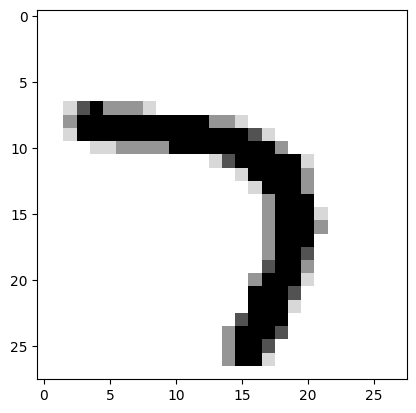

In [ ]:
# ทำนายผล
image_index = 60
plt.imshow(X_test[image_index].reshape(28, 28),cmap='Greys')
pred = model.predict(np.expand_dims(x_test_processed[0], axis=0))
print("Prediction probability array is:")

count = 0

for i in pred.squeeze():
    print(count, ":", i)
    count += 1

print("From which the max choice is:", pred.argmax())
print("Answer is:", y_test[image_index])